In [137]:


import os
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # for training and testing
from sklearn.linear_model import LogisticRegression # for using algorithm

In [138]:
df = pd.read_csv(r"G:\project\medical_disease_prediction\medical_disease_prediction_10000.csv")

In [139]:
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [140]:
df.duplicated().sum()

np.int64(0)

In [141]:
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
BloodPressure       0
GlucoseLevel        0
Cholesterol         0
HeartRate           0
Smoking             0
Alcohol             0
PhysicalActivity    0
FamilyHistory       0
Disease             0
dtype: int64

In [142]:
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,Male,27.1,177,183,268,59,No,No,High,No,Hypertension
9996,84,Male,29.2,142,215,145,77,No,Yes,High,Yes,Hypertension
9997,41,Male,22.8,177,265,133,71,No,No,Medium,Yes,Hypertension
9998,55,Male,29.0,126,241,298,57,No,No,Medium,Yes,Pre-Diabetes


In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   Gender            10000 non-null  str    
 2   BMI               10000 non-null  float64
 3   BloodPressure     10000 non-null  int64  
 4   GlucoseLevel      10000 non-null  int64  
 5   Cholesterol       10000 non-null  int64  
 6   HeartRate         10000 non-null  int64  
 7   Smoking           10000 non-null  str    
 8   Alcohol           10000 non-null  str    
 9   PhysicalActivity  10000 non-null  str    
 10  FamilyHistory     10000 non-null  str    
 11  Disease           10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB


In [144]:
df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy


In [145]:
df.shape


(10000, 12)

In [146]:
df.columns

Index(['Age', 'Gender', 'BMI', 'BloodPressure', 'GlucoseLevel', 'Cholesterol',
       'HeartRate', 'Smoking', 'Alcohol', 'PhysicalActivity', 'FamilyHistory',
       'Disease'],
      dtype='str')

In [147]:
df.describe()

,Age,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,50.755300,26.082000,135.023800,175.252000,219.313500,82.690100
std,19.242137,4.461098,26.249406,60.536159,57.940956,16.167628
min,18.000000,16.000000,90.000000,70.000000,120.000000,55.000000
25%,34.000000,23.000000,112.000000,123.000000,169.000000,69.000000
50%,51.000000,26.000000,135.000000,174.000000,219.000000,83.000000
75%,67.000000,29.100000,158.000000,227.000000,269.250000,97.000000
max,84.000000,44.700000,180.000000,280.000000,320.000000,110.000000


In [148]:
df['PhysicalActivity'].unique()

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [149]:
PhysicalActivity_dict={
       'Low':1,    'Medium':2,
        'High':3

}
df['PhysicalActivity'] = df['PhysicalActivity'].map(PhysicalActivity_dict)


In [150]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [151]:
Gender_dict = {
    'Male':1, 'Female':2

}
df['Gender'] = df['Gender'].map(Gender_dict)

In [152]:
df['Disease'].unique()


<StringArray>
['Healthy', 'Pre-Diabetes', 'Hypertension', 'Heart Disease', 'Diabetes']
Length: 5, dtype: str

In [153]:
Disease_dict = {
    'Healthy':1, 'Pre-Diabetes':2, 'Hypertension':3, 'Heart Disease':4, 'Diabetes':5

}
df['Disease']=df['Disease'].map(Disease_dict)

In [154]:
df['FamilyHistory'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [155]:
FamilyHistory_dict = {
     'No':0, 'Yes'  :1
}
df['FamilyHistory'] = df['FamilyHistory'].map(FamilyHistory_dict)

In [156]:
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,No,No,2,0,1
1,69,1,31.1,118,256,147,92,No,No,3,1,2
2,61,2,31.3,114,206,193,74,Yes,No,2,0,1
3,47,2,23.9,105,162,253,68,No,No,1,0,1
4,47,1,28.3,148,121,280,84,No,Yes,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,No,No,3,0,3
9996,84,1,29.2,142,215,145,77,No,Yes,3,1,3
9997,41,1,22.8,177,265,133,71,No,No,2,1,3
9998,55,1,29.0,126,241,298,57,No,No,2,1,2


In [157]:
df.drop('Smoking', axis=1, inplace=True)

In [158]:
df.drop('Alcohol', axis=1, inplace=True)

In [159]:
df

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,PhysicalActivity,FamilyHistory,Disease
0,23,1,17.5,102,177,161,88,2,0,1
1,69,1,31.1,118,256,147,92,3,1,2
2,61,2,31.3,114,206,193,74,2,0,1
3,47,2,23.9,105,162,253,68,1,0,1
4,47,1,28.3,148,121,280,84,3,0,1
...,...,...,...,...,...,...,...,...,...,...
9995,49,1,27.1,177,183,268,59,3,0,3
9996,84,1,29.2,142,215,145,77,3,1,3
9997,41,1,22.8,177,265,133,71,2,1,3
9998,55,1,29.0,126,241,298,57,2,1,2


In [160]:
df['Disease'].value_counts()

Disease
1    6329
3    1771
2    1453
4     232
5     215
Name: count, dtype: int64

<Axes: xlabel='Disease', ylabel='count'>

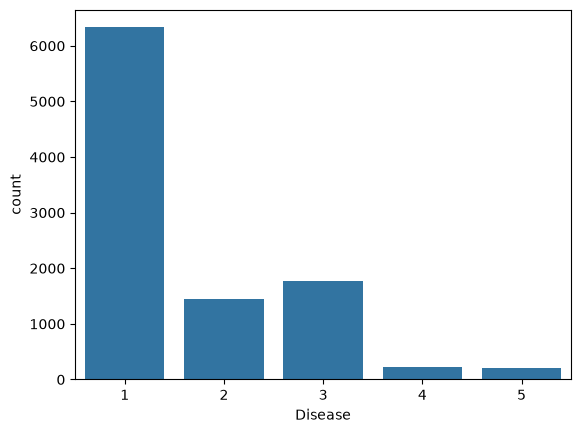

In [161]:
sns.countplot(x='Disease', data =df)

<Axes: xlabel='GlucoseLevel', ylabel='Count'>

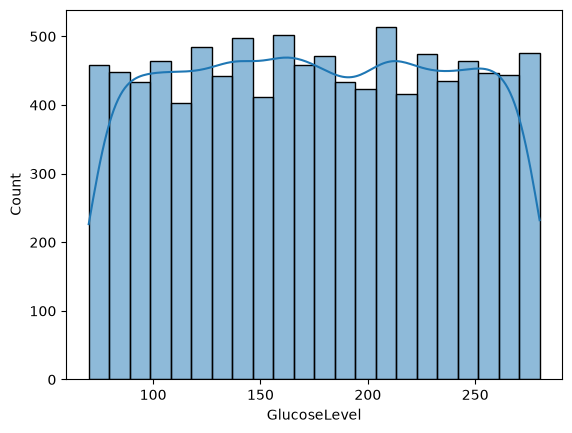

In [162]:
sns.histplot(df["GlucoseLevel"], kde =True)

<Axes: xlabel='Disease', ylabel='HeartRate'>

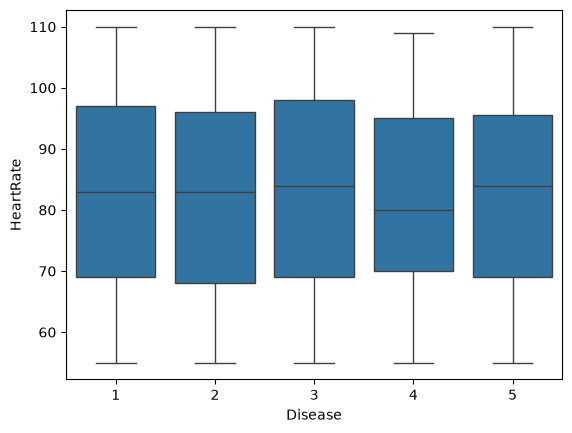

In [163]:
sns.boxplot(x='Disease',y ='HeartRate',data= df)

<Axes: >

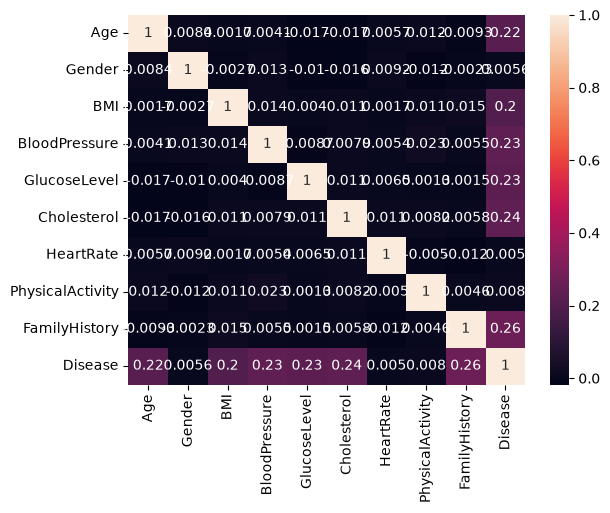

In [164]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [165]:
x = df.drop('Disease', axis=1)

In [166]:
y = df[['Disease']]

In [167]:
x_train, x_test, y_train, y_test =train_test_split(x , y,test_size=0.2,random_state=42)

In [168]:
x_train

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,PhysicalActivity,FamilyHistory
9254,76,1,29.6,134,266,318,101,2,1
1561,35,2,29.3,96,220,300,58,1,0
1670,69,1,29.6,164,149,229,98,1,0
6087,47,1,29.0,159,250,258,109,2,0
6669,42,1,23.4,107,224,300,82,2,0
...,...,...,...,...,...,...,...,...,...
5734,61,2,30.2,175,147,167,102,1,0
5191,79,2,20.5,150,225,142,84,2,1
5390,30,1,27.6,119,101,129,110,2,0
860,82,1,30.7,108,143,231,102,1,1


In [169]:
y_train

,Disease
9254,3
1561,1
1670,1
6087,1
6669,1
...,...
5734,2
5191,1
5390,1
860,3


In [170]:
x_test

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,PhysicalActivity,FamilyHistory
6252,36,1,23.5,122,156,146,99,2,1
4684,52,2,23.0,147,137,273,107,3,0
1731,78,1,26.3,118,128,125,55,2,1
4742,46,1,22.6,161,211,147,59,1,0
4521,64,2,27.2,126,261,162,108,2,0
...,...,...,...,...,...,...,...,...,...
6412,23,2,25.5,114,204,220,99,1,0
8285,20,1,32.3,131,257,287,77,1,0
7853,53,2,26.8,180,240,306,94,3,0
1095,23,2,35.2,118,148,292,100,1,0


In [171]:
y_test

,Disease
6252,1
4684,1
1731,1
4742,1
4521,3
...,...
6412,1
8285,1
7853,3
1095,1


In [172]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((8000, 9), (8000, 1), (2000, 9), (2000, 1))

In [173]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

g:\project\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
g:\project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [175]:
pred= lr.predict(x_test)

In [176]:
pred

array([1, 1, 1, ..., 1, 1, 1], shape=(2000,))

In [177]:
# Accuracy
print("Test Score -->",lr.score(x_test,y_test))       
print("Training score-->",lr.score(x_train,y_train))

Test Score --> 0.641
Training score--> 0.629125
